<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h2 style="margin-bottom: 6px;">Day 9 — Notebook 5</h2>
<h3 style="margin-top: 0;">Manual Out-of-Fold Stacking and Blending</h3>

<p>
This notebook continues after Notebook 4. In Notebook 4, we used <code>StackingClassifier</code>, which handled stacking internally.
In this notebook, we build the stacking logic manually so we can clearly see how <b>Out-of-Fold predictions</b> become meta-features.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Notebook objective:</b><br>
  Build manual <b>Out-of-Fold stacking</b>, build <b>Blending</b> using a 70/30 split, and compare both methods on the held-out test set.
</div>

<p>
The code is intentionally simple and heavily commented. The goal is not only to get a score, but to understand exactly how stacking and blending work.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important points for understanding</h3>

<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Concept</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Simple meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><b>OOF prediction</b></td>
      <td style="padding: 6px;">A prediction made for a row by a model that did not train on that row.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Meta-feature</b></td>
      <td style="padding: 6px;">A base model prediction used as input for the final meta-model.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Manual stacking</b></td>
      <td style="padding: 6px;">We create the meta-features ourselves using folds.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Blending</b></td>
      <td style="padding: 6px;">A simpler method: train base models on 70% and train the meta-model on the remaining 30%.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Data leakage</b></td>
      <td style="padding: 6px;">When the model accidentally learns from data it should not see.</td>
    </tr>
  </tbody>
</table>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important warning:</b><br>
  In stacking, the meta-model must not learn from base-model predictions that were created on the same rows used to train those base models.
  That is why OOF predictions are important.
</div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">3. Build Manual Out-of-Fold Predictions</h3>

<p>
In this section, we create the new training table for the meta-model.
This new table does not use the original customer columns directly.
Instead, it uses prediction probabilities from the base models.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  For each fold, a base model trains on <b>4 folds</b> and predicts the <b>1 hidden fold</b>.
  These fair predictions are called <b>Out-of-Fold predictions</b>.
</div>

<p>
At the end of this step, every training row will have one fair prediction from each base model:
Random Forest, Logistic Regression, KNN, and Decision Tree.
These prediction columns become the input for the meta-model.
</p>

<p>
This avoids leakage because the meta-model learns from predictions made on rows that the base models did not train on.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Safe-Run Update</h3>

<p>
This notebook builds manual OOF stacking and blending step by step. Because this workflow trains many models repeatedly,
this version uses safe laptop settings: fewer Random Forest trees, no parallel Random Forest jobs, and fewer blending stability seeds.
The learning goal stays the same, but the notebook is less likely to overload the kernel.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important:</b><br>
  Run the notebook cell by cell. Manual OOF stacking can still take a few minutes because it trains models inside each fold.
</div>

</div>


In [1]:
# Limit heavy parallel processing before importing numerical libraries.
# This makes the notebook safer on laptops and helps avoid kernel crashes.

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Core data handling libraries
import pandas as pd
import numpy as np

# Plotting library
import matplotlib.pyplot as plt

# File and model saving utilities
from pathlib import Path
import joblib
import gc

# Scikit-learn preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn model selection tools
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.base import clone

# Scikit-learn evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# Base models and meta-models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Global random seed for reproducible results
RANDOM_STATE = 42

# Safe-run settings.
# The previous version used heavier parallel Random Forest training many times.
# This version keeps the learning goal the same but reduces crash risk.

RF_TREES_SAFE = 50
RF_N_JOBS_SAFE = 1
BLENDING_SEED_LIST = [11, 22, 33]

print("Notebook 5 safe-run settings loaded.")
print(f"Random Forest trees per run: {RF_TREES_SAFE}")
print(f"Random Forest n_jobs: {RF_N_JOBS_SAFE}")
print(f"Blending stability seeds: {BLENDING_SEED_LIST}")


Notebook 5 safe-run settings loaded.
Random Forest trees per run: 50
Random Forest n_jobs: 1
Blending stability seeds: [11, 22, 33]


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">1. Load data from Notebook 2</h3>

<p>
We continue from the same prepared train/test split used in Notebooks 3 and 4.
The training set is used to build OOF stacking and blending. The held-out test set is used only for final evaluation.
</p>

</div>

In [2]:
# Define project folders used across Day 9 notebooks.
# These paths are relative, so the notebook remains portable.

data_dir = Path("data")
processed_dir = data_dir / "processed"
reports_dir = Path("reports")
models_dir = Path("models")
figures_dir = Path("figures")

# Create output folders if they do not exist yet.

reports_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

# Define files created by Notebook 2.

X_train_path = processed_dir / "day9_X_train_raw.csv"
X_test_path = processed_dir / "day9_X_test_raw.csv"
y_train_path = processed_dir / "day9_y_train.csv"
y_test_path = processed_dir / "day9_y_test.csv"

# Check whether required files exist before loading.

required_files = [X_train_path, X_test_path, y_train_path, y_test_path]
missing_files = [str(file_path) for file_path in required_files if not file_path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Notebook 5 needs the train/test files from Notebook 2. "
        f"Missing files: {missing_files}"
    )

# Load raw train/test features.
# These are still raw; preprocessing will happen inside each pipeline.

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)

# Load target vectors and convert them into Series.

y_train = pd.read_csv(y_train_path).squeeze("columns")
y_test = pd.read_csv(y_test_path).squeeze("columns")

print("Data loaded successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Data loaded successfully.
X_train shape: (8929, 16)
X_test shape:  (2233, 16)
y_train shape: (8929,)
y_test shape:  (2233,)


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">2. Rebuild preprocessing and base models</h3>

<p>
We use the same preprocessing idea as earlier notebooks: numeric features are imputed and scaled, while categorical features are imputed and one-hot encoded.
Each base model is wrapped inside a pipeline, so preprocessing stays inside the training process.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point:</b><br>
  Putting preprocessing inside the pipeline prevents data leakage. In each fold, the preprocessor is fitted only on the fold-training data.
</div>

</div>

In [3]:
# Separate numeric and categorical columns from the raw feature table.

numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Categorical columns ({len(categorical_columns)}): {categorical_columns}")

# Numeric preprocessing:
# 1. Fill missing numeric values with the median.
# 2. Scale values for models such as Logistic Regression and KNN.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing:
# 1. Fill missing categories with the most frequent value.
# 2. Convert categorical columns into one-hot encoded columns.

try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Compatibility fallback for older scikit-learn versions.
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", categorical_encoder),
])

# Combine numeric and categorical preprocessing into one transformer.

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_columns),
    ("categorical", categorical_transformer, categorical_columns),
])

Numeric columns (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Helper Functions

In [4]:
# Helper function to create a full modelling pipeline.

def make_pipeline_for_model(model):
    """Create a pipeline with preprocessing + model."""
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

# Define the same four base learner types used in Notebook 4.
# Safe update: Random Forest uses fewer trees and no parallel jobs to avoid kernel crashes.

base_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=RF_TREES_SAFE,
        max_features=0.5,
        random_state=RANDOM_STATE,
        n_jobs=RF_N_JOBS_SAFE,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15,
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
    ),
}

# These names become the meta-feature column names.

meta_feature_names = [f"{model_name}_proba" for model_name in base_models.keys()]

print("Base models prepared:")
for model_name in base_models.keys():
    print(f"- {model_name}")

Base models prepared:
- Random Forest
- Logistic Regression
- KNN
- Decision Tree


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">3. Build Manual Out-of-Fold Predictions</h3>

<p>
In this section, we create the new training table for the meta-model.
This new table does not use the original customer columns directly.
Instead, it uses prediction probabilities from the base models.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  Each base model trains on part of the training data, then predicts the fold it did not see.
  These fair predictions are called <b>Out-of-Fold predictions</b>.
</div>

<p>
At the end of this step, every training row will have one prediction from each base model:
Random Forest, Logistic Regression, KNN, and Decision Tree.
These prediction columns become the input for the meta-model.
</p>

<p>
This avoids leakage because the meta-model learns from predictions made on rows that the base models did not train on.
</p>

</div>

In [5]:
# Create a 5-fold stratified CV strategy.
# Stratified means each fold keeps a similar subscribed/not-subscribed ratio.

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Create empty arrays to store meta-features.
# oof_train_predictions will hold base-model probabilities for each training row.

oof_train_predictions = np.zeros((len(X_train), len(base_models)))

# test_predictions_by_fold stores test probabilities from each fold-trained model.
# Later we average these fold predictions for the test meta-features.

test_predictions_by_fold = np.zeros((len(X_test), len(base_models), cv_strategy.get_n_splits()))

# Store fold-level quality checks for each base model.

fold_score_rows = []

# Loop through the five folds.

for fold_number, (fold_train_index, fold_valid_index) in enumerate(cv_strategy.split(X_train, y_train), start=1):
    print(f"Starting fold {fold_number}")

    # Split training data into fold-training and fold-validation parts.
    # The validation fold is the part that the base model has not seen.
    
    X_fold_train = X_train.iloc[fold_train_index]
    y_fold_train = y_train.iloc[fold_train_index]
    X_fold_valid = X_train.iloc[fold_valid_index]
    y_fold_valid = y_train.iloc[fold_valid_index]

    # Train every base model on the fold-training part.
    
    for model_position, (model_name, model) in enumerate(base_models.items()):
        print(f"  Training base model: {model_name}")

        # clone(model) gives a fresh copy of the model for this fold.
        # This prevents one fold's fitted model from leaking into another fold.
        
        fold_pipeline = make_pipeline_for_model(clone(model))

        # Fit preprocessing + model only on the fold-training data.
        
        fold_pipeline.fit(X_fold_train, y_fold_train)

        # Predict probabilities for the validation fold.
        # These are fair OOF predictions because the model did not train on these rows.
        
        valid_probability = fold_pipeline.predict_proba(X_fold_valid)[:, 1]

        # Store OOF predictions in the correct original row positions.
        
        oof_train_predictions[fold_valid_index, model_position] = valid_probability

        # Also predict the held-out test set with this fold-trained model.
        # We average these test predictions across folds later.
        test_probability = fold_pipeline.predict_proba(X_test)[:, 1]
        test_predictions_by_fold[:, model_position, fold_number - 1] = test_probability

        # Convert validation probabilities to 0/1 labels for a quick fold F1 check.
        valid_prediction = (valid_probability >= 0.5).astype(int)
        fold_score_rows.append({
            "Fold": fold_number,
            "Base_Model": model_name,
            "Validation_F1": f1_score(y_fold_valid, valid_prediction, zero_division=0),
            "Validation_ROC_AUC": roc_auc_score(y_fold_valid, valid_probability),
        })

        # Free fitted model memory before the next model starts.
        del fold_pipeline
        gc.collect()

    # Free temporary fold data references.
    del X_fold_train, y_fold_train, X_fold_valid, y_fold_valid
    gc.collect()

print("Manual OOF predictions created successfully.")


Starting fold 1
  Training base model: Random Forest
  Training base model: Logistic Regression
  Training base model: KNN
  Training base model: Decision Tree
Starting fold 2
  Training base model: Random Forest
  Training base model: Logistic Regression
  Training base model: KNN
  Training base model: Decision Tree
Starting fold 3
  Training base model: Random Forest
  Training base model: Logistic Regression
  Training base model: KNN
  Training base model: Decision Tree
Starting fold 4
  Training base model: Random Forest
  Training base model: Logistic Regression
  Training base model: KNN
  Training base model: Decision Tree
Starting fold 5
  Training base model: Random Forest
  Training base model: Logistic Regression
  Training base model: KNN
  Training base model: Decision Tree
Manual OOF predictions created successfully.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">4. Inspect the Out-of-Fold Meta-Feature Table</h3>

<p>
This table shows the <b>new prediction-based features</b> created by the base models.
Each row is one training customer, and each column is one base model's predicted probability
that the customer will subscribe.
</p>

<p>
These are called <b>Out-of-Fold predictions</b> because each prediction was made by a model
that did <b>not</b> train on that specific row.
This makes the predictions fair for training the meta-model.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple meaning:</b><br>
  The base models first give their opinions.
  Then the meta-model learns how to combine those opinions.
</div>

<p>
So this table becomes the <b>new training input for the meta-model</b>.
Instead of learning directly from columns like age, balance, job, and campaign,
the meta-model learns from prediction columns such as Random Forest probability,
Logistic Regression probability, KNN probability, and Decision Tree probability.
</p>

</div>

In [6]:
# Convert the OOF prediction array into a readable DataFrame.
oof_meta_train = pd.DataFrame(
    oof_train_predictions,
    columns=meta_feature_names,
)

# Average test probabilities across the five fold-trained versions of each base model.
oof_meta_test = pd.DataFrame(
    test_predictions_by_fold.mean(axis=2),
    columns=meta_feature_names,
)

# Convert fold score rows into a table for inspection.
fold_scores = pd.DataFrame(fold_score_rows)
fold_scores_summary = (
    fold_scores
    .groupby("Base_Model", as_index=False)
    .agg(
        Mean_Validation_F1=("Validation_F1", "mean"),
        Std_Validation_F1=("Validation_F1", "std"),
        Mean_Validation_ROC_AUC=("Validation_ROC_AUC", "mean"),
        Std_Validation_ROC_AUC=("Validation_ROC_AUC", "std"),
    )
    .sort_values("Mean_Validation_F1", ascending=False)
)

# Round for display.
fold_scores_summary_rounded = fold_scores_summary.copy()
metric_columns = [col for col in fold_scores_summary_rounded.columns if col != "Base_Model"]
fold_scores_summary_rounded[metric_columns] = fold_scores_summary_rounded[metric_columns].round(4)

print("OOF meta-feature table shape:", oof_meta_train.shape)
print("Test meta-feature table shape:", oof_meta_test.shape)

print("\nOOF meta-feature preview:")
display(oof_meta_train.head())

print("\nBase-model OOF fold quality summary:")
display(fold_scores_summary_rounded)

OOF meta-feature table shape: (8929, 4)
Test meta-feature table shape: (2233, 4)

OOF meta-feature preview:


,Random Forest_proba,Logistic Regression_proba,KNN_proba,Decision Tree_proba
0,0.00,0.199156,0.200000,0.0
1,1.00,0.985255,1.000000,1.0
2,0.98,0.686134,0.866667,1.0
3,0.62,0.791250,0.666667,0.0
4,0.70,0.749639,0.466667,1.0



Base-model OOF fold quality summary:


,Base_Model,Mean_Validation_F1,Std_Validation_F1,Mean_Validation_ROC_AUC,Std_Validation_ROC_AUC
3,Random Forest,0.8492,0.0042,0.9181,0.0049
2,Logistic Regression,0.8108,0.0113,0.9015,0.0048
1,KNN,0.7899,0.0130,0.8902,0.0067
0,Decision Tree,0.7819,0.0025,0.7932,0.0014


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: OOF Meta-Features</h3>

<p>
The <b>OOF meta-feature table</b> has shape <b>(8929, 4)</b>.
This means we created prediction-based features for <b>8,929 training rows</b>
using <b>4 base models</b>.
</p>

<p>
The <b>test meta-feature table</b> has shape <b>(2233, 4)</b>.
This means we also created prediction-based features for <b>2,233 test rows</b>
using the same 4 base models.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple meaning:</b><br>
  Each row is one customer. Each column is one base model's predicted probability
  that the customer will subscribe.
</div>

<p>
The four meta-feature columns are:
<b>Random Forest probability</b>, <b>Logistic Regression probability</b>,
<b>KNN probability</b>, and <b>Decision Tree probability</b>.
These columns will become the input for the meta-model.
</p>

<p>
The fold quality summary shows that <b>Random Forest</b> is the strongest base model,
with a mean validation F1-score of <b>0.8492</b> and mean validation ROC-AUC of <b>0.9181</b>.
Logistic Regression is the second strongest model, followed by KNN and Decision Tree.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main conclusion:</b><br>
  The OOF prediction table was created successfully.
  Every training row now has fair prediction probabilities from the base models.
  The next step is to train the meta-model using these prediction columns.
</div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">5. Train the Manual OOF Stacking Meta-Model</h3>

<p>
Now we train the <b>meta-model</b>. 
This is the final model that learns how to combine the predictions from the base models.
</p>

<p>
The meta-model does <b>not</b> learn from the original customer columns like age, job, balance, or campaign.
Instead, it learns from the new OOF prediction table created in the previous step.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  The base models gave their opinions first.
  Now the meta-model learns how to combine those opinions into one final prediction.
</div>

<p>
The input columns for the meta-model are:
<b>Random Forest probability</b>, <b>Logistic Regression probability</b>,
<b>KNN probability</b>, and <b>Decision Tree probability</b>.
</p>

<p>
In this notebook, we use <b>Logistic Regression</b> as the meta-model because it is simple,
stable, and easy to understand. It learns which base-model predictions are more useful for predicting customer subscription.
</p>

</div>

In [7]:
# Train a simple, explainable meta-model on the OOF predictions.

manual_oof_meta_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

# Fit the meta-model using OOF predictions as inputs and the real target as output.

manual_oof_meta_model.fit(oof_meta_train, y_train)

# Predict the held-out test set using averaged fold-based test meta-features.

manual_oof_pred = manual_oof_meta_model.predict(oof_meta_test)
manual_oof_proba = manual_oof_meta_model.predict_proba(oof_meta_test)[:, 1]

# Store manual OOF stacking test results.

manual_oof_result = {
    "Model": "Manual OOF Stacking",
    "Test_Accuracy": accuracy_score(y_test, manual_oof_pred),
    "Test_Precision": precision_score(y_test, manual_oof_pred, zero_division=0),
    "Test_Recall": recall_score(y_test, manual_oof_pred, zero_division=0),
    "Test_F1": f1_score(y_test, manual_oof_pred, zero_division=0),
    "Test_ROC_AUC": roc_auc_score(y_test, manual_oof_proba),
}

manual_oof_result_table = pd.DataFrame([manual_oof_result])
manual_oof_result_rounded = manual_oof_result_table.copy()
metric_columns = [col for col in manual_oof_result_rounded.columns if col != "Model"]
manual_oof_result_rounded[metric_columns] = manual_oof_result_rounded[metric_columns].round(4)

display(manual_oof_result_rounded)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Manual OOF Stacking,0.8603,0.8354,0.8781,0.8562,0.9259


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">6. Build Blending with a 70/30 Split</h3>

<p>
In this section, we build <b>Blending</b>.
Blending is another way to train a stacking-style model, but it is simpler than manual OOF stacking.
</p>

<p>
The main idea is to split the training data one more time:
<b>70%</b> of the training data is used to train the base models, and the remaining <b>30%</b>
is used to train the meta-model.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  Base models learn from the 70% training part.
  Then they predict the 30% blending part.
  Those prediction columns are used to train the meta-model.
</div>

<p>
So the variable flow is:
</p>

<ul>
  <li><code>X_base_train</code> and <code>y_base_train</code> train the base models.</li>
  <li><code>X_blend_train</code> is predicted by the trained base models.</li>
  <li>The base-model predictions on <code>X_blend_train</code> become the blending meta-features.</li>
  <li>The meta-model learns from those blending meta-features and <code>y_blend_train</code>.</li>
</ul>

<p>
This is easier than OOF stacking because we do not repeat the process across 5 folds.
We only split the data once and train the base models once.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important limitation:</b><br>
  Blending is simpler, but it can be less stable.
  The result depends strongly on which rows land in the 70% base-training part
  and which rows land in the 30% blending part.
</div>

<p>
In short, <b>OOF stacking uses all training rows more carefully across folds</b>,
while <b>blending is faster and easier but more dependent on one split</b>.
</p>

</div>

In [8]:
# Split the training data into two parts for blending.
# 70% trains base models; 30% trains the meta-model.

X_base_train, X_blend_valid, y_base_train, y_blend_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.30,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f"Base-model training data shape: {X_base_train.shape}")
print(f"Blend meta-model data shape:  {X_blend_valid.shape}")

# Empty arrays for blending meta-features.

blend_valid_predictions = np.zeros((len(X_blend_valid), len(base_models)))
blend_test_predictions = np.zeros((len(X_test), len(base_models)))

# Train each base model on the 70% base-training split.

for model_position, (model_name, model) in enumerate(base_models.items()):
    print(f"Training blend base model: {model_name}")

    # Fresh pipeline for this model.
    
    blend_pipeline = make_pipeline_for_model(clone(model))

    # Base models only see the 70% base-training data.
    
    blend_pipeline.fit(X_base_train, y_base_train)

    # Predictions on the 30% blend-validation data become meta-training features.
    
    blend_valid_predictions[:, model_position] = blend_pipeline.predict_proba(X_blend_valid)[:, 1]

    # Predictions on the held-out test set become test meta-features.
    
    blend_test_predictions[:, model_position] = blend_pipeline.predict_proba(X_test)[:, 1]

    # Free fitted model memory before the next model starts.
    
    del blend_pipeline
    gc.collect()

# Create readable blending meta-feature tables.

blend_meta_train = pd.DataFrame(blend_valid_predictions, columns=meta_feature_names)
blend_meta_test = pd.DataFrame(blend_test_predictions, columns=meta_feature_names)

print("Blending meta-features created successfully.")
display(blend_meta_train.head())


Base-model training data shape: (6250, 16)
Blend meta-model data shape:  (2679, 16)
Training blend base model: Random Forest
Training blend base model: Logistic Regression
Training blend base model: KNN
Training blend base model: Decision Tree
Blending meta-features created successfully.


,Random Forest_proba,Logistic Regression_proba,KNN_proba,Decision Tree_proba
0,0.82,0.915855,0.933333,1.0
1,0.18,0.142122,0.066667,0.0
2,0.76,0.481211,0.400000,1.0
3,0.86,0.615980,0.866667,1.0
4,0.94,0.999133,0.733333,1.0


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Blending Meta-Features</h3>

<p>
The blending split was created successfully.
The base models were trained on <b>6,250 rows</b>, and the meta-model will be trained on <b>2,679 rows</b>.
</p>

<p>
This means the training data was split into two parts:
</p>

<ul>
  <li><b>Base-model training data:</b> used to train Random Forest, Logistic Regression, KNN, and Decision Tree.</li>
  <li><b>Blend meta-model data:</b> used to create prediction columns for the meta-model.</li>
</ul>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple meaning:</b><br>
  The base models learned from the 70% training part.
  Then they predicted the 30% blending part.
  Those predictions became the new input columns for the meta-model.
</div>

<p>
The preview table shows the new blending meta-features.
Each row is one customer from the blending part, and each column is one base model's predicted probability
that the customer will subscribe.
</p>

<p>
For example, in the first row, all base models give high probabilities.
This means the models mostly agree that the customer is likely to subscribe.
In the second row, all probabilities are low.
This means the models mostly agree that the customer is unlikely to subscribe.
</p>

<p>
Sometimes the models disagree.
For example, one model may give a high probability while another gives a medium or low probability.
This disagreement is useful because the meta-model can learn which model to trust more in different situations.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main conclusion:</b><br>
  The blending meta-feature table was created successfully.
  The next step is to train the blending meta-model using these prediction columns.
</div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">7. Train the blending meta-model</h3>

<p>
The blending meta-model learns from the 30% blend-validation split.
It receives base-model probability predictions as inputs and learns how to combine them.
</p>

</div>

In [9]:
# Train the blending meta-model.
blend_meta_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

# The target for blending meta-training is y_blend_valid.
blend_meta_model.fit(blend_meta_train, y_blend_valid)

# Evaluate blending on the held-out test set.
blend_pred = blend_meta_model.predict(blend_meta_test)
blend_proba = blend_meta_model.predict_proba(blend_meta_test)[:, 1]

blend_result = {
    "Model": "Blending 70/30",
    "Test_Accuracy": accuracy_score(y_test, blend_pred),
    "Test_Precision": precision_score(y_test, blend_pred, zero_division=0),
    "Test_Recall": recall_score(y_test, blend_pred, zero_division=0),
    "Test_F1": f1_score(y_test, blend_pred, zero_division=0),
    "Test_ROC_AUC": roc_auc_score(y_test, blend_proba),
}

blend_result_table = pd.DataFrame([blend_result])
blend_result_rounded = blend_result_table.copy()
metric_columns = [col for col in blend_result_rounded.columns if col != "Model"]
blend_result_rounded[metric_columns] = blend_result_rounded[metric_columns].round(4)

display(blend_result_rounded)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Blending 70/30,0.8554,0.8314,0.8715,0.8509,0.9232


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">8. Compare manual OOF stacking vs blending</h3>

<p>
Now we compare both methods on the same held-out test set.
This shows whether the more careful OOF approach gives better performance than the simpler blending approach.
</p>

</div>

In [10]:
# Combine manual OOF stacking and blending results.
manual_stacking_vs_blending = pd.DataFrame([
    manual_oof_result,
    blend_result,
]).sort_values("Test_F1", ascending=False).reset_index(drop=True)

# Add a short method description for interpretation.
method_notes = {
    "Manual OOF Stacking": "Uses 5 folds to create fair meta-features for all training rows.",
    "Blending 70/30": "Uses one 70/30 split; simpler but more split-dependent.",
}
manual_stacking_vs_blending["Method_Note"] = manual_stacking_vs_blending["Model"].map(method_notes)

# Round numeric columns for display.
comparison_rounded = manual_stacking_vs_blending.copy()
metric_columns = [col for col in comparison_rounded.columns if col not in ["Model", "Method_Note"]]
comparison_rounded[metric_columns] = comparison_rounded[metric_columns].round(4)

display(comparison_rounded)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Method_Note
0,Manual OOF Stacking,0.8603,0.8354,0.8781,0.8562,0.9259,Uses 5 folds to create fair meta-features for ...
1,Blending 70/30,0.8554,0.8314,0.8715,0.8509,0.9232,Uses one 70/30 split; simpler but more split-d...


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Manual OOF Stacking vs Blending</h3>

<p>
This table compares the two manual stacking approaches tested in this notebook:
<b>Manual OOF Stacking</b> and <b>Blending with a 70/30 split</b>.
Both methods use base-model prediction columns to train a meta-model, but they create those columns differently.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best result:</b><br>
  <b>Manual OOF Stacking</b> performed better than Blending.
  It achieved a <b>test F1-score of 0.8562</b> and a <b>test ROC-AUC of 0.9259</b>.
</div>

<p>
Manual OOF Stacking also achieved slightly better test accuracy:
<b>0.8603</b> compared with <b>0.8554</b> for Blending.
This means OOF stacking made slightly more correct predictions overall on the held-out test set.
</p>

<p>
The precision scores are also close.
Manual OOF Stacking achieved <b>0.8354</b>, while Blending achieved <b>0.8314</b>.
This means Manual OOF Stacking was slightly better when predicting which customers would subscribe.
</p>

<p>
The recall score is also higher for Manual OOF Stacking:
<b>0.8781</b> compared with <b>0.8715</b> for Blending.
This means Manual OOF Stacking caught slightly more actual subscribers.
For a marketing campaign, this is useful because missing potential subscribers can reduce campaign opportunity.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple explanation:</b><br>
  OOF stacking is more careful because it uses 5 folds to create fair meta-features.
  Blending is simpler because it uses only one 70/30 split, but that also makes it more dependent on one split.
</div>

<p>
The result confirms the expected behaviour:
<b>Blending is easier and faster</b>, but <b>Manual OOF Stacking is more stable and slightly stronger</b>.
</p>

<p>
For this notebook, Manual OOF Stacking is the better method because it has the strongest F1-score,
ROC-AUC, accuracy, precision, and recall among the two methods.
</p>

</div>

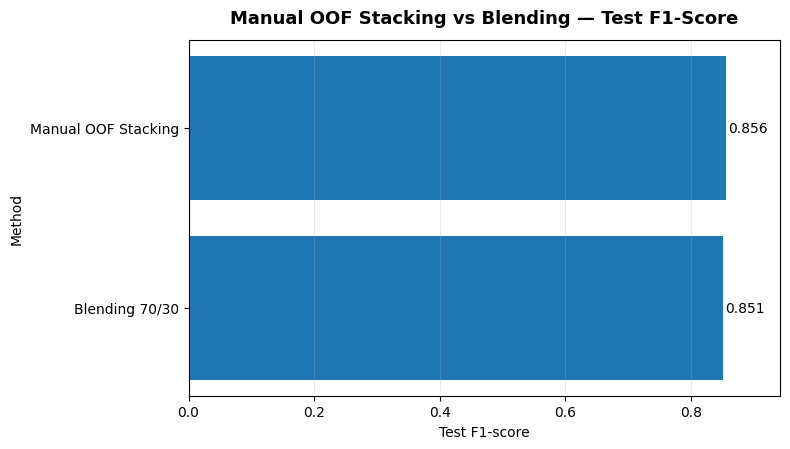

In [11]:
# Plot the F1-score comparison.
plot_data = manual_stacking_vs_blending.sort_values("Test_F1", ascending=True)

plt.figure(figsize=(8, 4.6))
bars = plt.barh(plot_data["Model"], plot_data["Test_F1"])

plt.title("Manual OOF Stacking vs Blending — Test F1-Score", fontsize=13, weight="bold", pad=12)
plt.xlabel("Test F1-score")
plt.ylabel("Method")
plt.grid(axis="x", alpha=0.25)

# Add value labels to the bars.
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

plt.xlim(0, max(plot_data["Test_F1"]) * 1.10)
plt.tight_layout()
plt.savefig(figures_dir / "day9_notebook5_oof_vs_blending_f1.png", dpi=160, bbox_inches="tight")
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">9. Blending stability check</h3>

<p>
Because blending depends on one 70/30 split, we test it with a few different random splits.
If the scores change a lot, blending is less stable. If the scores stay close, blending is more stable.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  OOF stacking uses several folds by design. Blending is simpler, so we check whether different split seeds change the result.
</div>

</div>

In [12]:
# Helper function to run blending once with a given random seed.

def run_blending_once(seed):
    """Run one 70/30 blending experiment and return test metrics."""

    # Create one 70/30 split of the training data.
    X_base, X_blend, y_base, y_blend = train_test_split(
        X_train,
        y_train,
        test_size=0.30,
        stratify=y_train,
        random_state=seed,
    )

    # Prepare meta-feature arrays for this split.
    split_blend_predictions = np.zeros((len(X_blend), len(base_models)))
    split_test_predictions = np.zeros((len(X_test), len(base_models)))

    # Train base models on the 70% base-training data.
    for model_position, (model_name, model) in enumerate(base_models.items()):
        split_pipeline = make_pipeline_for_model(clone(model))
        split_pipeline.fit(X_base, y_base)

        # Predict 30% blend split and test set.
        split_blend_predictions[:, model_position] = split_pipeline.predict_proba(X_blend)[:, 1]
        split_test_predictions[:, model_position] = split_pipeline.predict_proba(X_test)[:, 1]

        # Free fitted model memory before the next model starts.
        del split_pipeline
        gc.collect()

    # Build meta-feature tables.
    split_meta_train = pd.DataFrame(split_blend_predictions, columns=meta_feature_names)
    split_meta_test = pd.DataFrame(split_test_predictions, columns=meta_feature_names)

    # Train the blending meta-model.
    split_meta_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    split_meta_model.fit(split_meta_train, y_blend)

    # Predict test set and return metrics.
    split_pred = split_meta_model.predict(split_meta_test)
    split_proba = split_meta_model.predict_proba(split_meta_test)[:, 1]

    result = {
        "Seed": seed,
        "Test_Accuracy": accuracy_score(y_test, split_pred),
        "Test_F1": f1_score(y_test, split_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, split_proba),
    }

    # Free temporary objects before returning.
    del split_meta_model, split_meta_train, split_meta_test
    del X_base, X_blend, y_base, y_blend
    gc.collect()

    return result

# Run blending with a few different split seeds.
# Safe update: three seeds are enough to show split-dependence without overloading the kernel.
blending_stability_results = pd.DataFrame([
    run_blending_once(seed) for seed in BLENDING_SEED_LIST
])

# Create a summary showing average and variation across different blending splits.
blending_stability_summary = pd.DataFrame([{
    "Method": "Blending 70/30 stability check",
    "Mean_Test_Accuracy": blending_stability_results["Test_Accuracy"].mean(),
    "Std_Test_Accuracy": blending_stability_results["Test_Accuracy"].std(),
    "Mean_Test_F1": blending_stability_results["Test_F1"].mean(),
    "Std_Test_F1": blending_stability_results["Test_F1"].std(),
    "Mean_Test_ROC_AUC": blending_stability_results["Test_ROC_AUC"].mean(),
    "Std_Test_ROC_AUC": blending_stability_results["Test_ROC_AUC"].std(),
}])

# Round for display.
blending_stability_display = blending_stability_results.copy()
metric_columns = [col for col in blending_stability_display.columns if col != "Seed"]
blending_stability_display[metric_columns] = blending_stability_display[metric_columns].round(4)

blending_stability_summary_display = blending_stability_summary.copy()
metric_columns = [col for col in blending_stability_summary_display.columns if col != "Method"]
blending_stability_summary_display[metric_columns] = blending_stability_summary_display[metric_columns].round(4)

print("Blending results across different 70/30 splits:")
display(blending_stability_display)

print("\nBlending stability summary:")
display(blending_stability_summary_display)


Blending results across different 70/30 splits:


,Seed,Test_Accuracy,Test_F1,Test_ROC_AUC
0,11,0.8549,0.8506,0.9217
1,22,0.8576,0.8533,0.9217
2,33,0.8571,0.8535,0.9250



Blending stability summary:


,Method,Mean_Test_Accuracy,Std_Test_Accuracy,Mean_Test_F1,Std_Test_F1,Mean_Test_ROC_AUC,Std_Test_ROC_AUC
0,Blending 70/30 stability check,0.8565,0.0014,0.8524,0.0016,0.9228,0.0019


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Blending Stability Check</h3>

<p>
This table checks how stable the <b>Blending 70/30 method</b> is when we change the random split.
We tested three different split seeds: <b>11</b>, <b>22</b>, and <b>33</b>.
</p>

<p>
Each seed creates a slightly different 70/30 split:
</p>

<ul>
  <li><b>70%</b> of the training data is used to train the base models.</li>
  <li><b>30%</b> of the training data is used to train the meta-model.</li>
</ul>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  If the results change a lot across different seeds, blending is unstable.
  If the results stay close, blending is reasonably stable.
</div>

<p>
The results are quite close across the three seeds.
The test accuracy stays between <b>0.8549</b> and <b>0.8576</b>.
The test F1-score stays between <b>0.8506</b> and <b>0.8535</b>.
The test ROC-AUC stays between <b>0.9217</b> and <b>0.9250</b>.
</p>

<p>
This means the blending approach is not crashing or behaving randomly.
However, the result still depends on which rows are placed into the 70% base-training part
and which rows are placed into the 30% meta-model part.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point:</b><br>
  Blending is simpler than OOF stacking, but it is more split-dependent.
  A different 70/30 split can slightly change the final model performance.
</div>

<p>
Overall, blending is reasonably stable here, but <b>Manual OOF Stacking remains the stronger method</b>
because it uses 5 folds to create fair meta-features more carefully.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">10. Save Notebook 5 outputs</h3>

<p>
We save the key results so Notebook 6 and the final project summary can reuse them.
</p>

</div>

In [13]:
# Save main comparison tables.
fold_scores_summary_rounded.to_csv(
    reports_dir / "day9_notebook5_oof_base_fold_summary.csv",
    index=False,
)

manual_oof_result_rounded.to_csv(
    reports_dir / "day9_notebook5_manual_oof_result.csv",
    index=False,
)

blend_result_rounded.to_csv(
    reports_dir / "day9_notebook5_blending_result.csv",
    index=False,
)

comparison_rounded.to_csv(
    reports_dir / "day9_notebook5_oof_vs_blending_comparison.csv",
    index=False,
)

blending_stability_display.to_csv(
    reports_dir / "day9_notebook5_blending_stability_results.csv",
    index=False,
)

blending_stability_summary_display.to_csv(
    reports_dir / "day9_notebook5_blending_stability_summary.csv",
    index=False,
)

# Save meta-feature tables for transparency.
oof_meta_train.to_csv(
    reports_dir / "day9_notebook5_oof_meta_train_features.csv",
    index=False,
)

oof_meta_test.to_csv(
    reports_dir / "day9_notebook5_oof_meta_test_features.csv",
    index=False,
)

# Save the trained meta-models.
joblib.dump(
    manual_oof_meta_model,
    models_dir / "day9_manual_oof_meta_model.joblib",
)

joblib.dump(
    blend_meta_model,
    models_dir / "day9_blending_meta_model.joblib",
)

# Save a short summary for the next notebook.
notebook5_summary = pd.DataFrame([{
    "Best_Notebook5_Method": manual_stacking_vs_blending.iloc[0]["Model"],
    "Best_Notebook5_Test_F1": manual_stacking_vs_blending.iloc[0]["Test_F1"],
    "Best_Notebook5_Test_ROC_AUC": manual_stacking_vs_blending.iloc[0]["Test_ROC_AUC"],
    "Blending_F1_Std_Across_Splits": blending_stability_results["Test_F1"].std(),
}])

notebook5_summary.to_csv(
    reports_dir / "day9_notebook5_summary.csv",
    index=False,
)

print("Notebook 5 outputs saved successfully.")
print(f"Reports saved in: {reports_dir}")
print(f"Models saved in: {models_dir}")
print(f"Figures saved in: {figures_dir}")

display(notebook5_summary.round(4))

Notebook 5 outputs saved successfully.
Reports saved in: reports
Models saved in: models
Figures saved in: figures


,Best_Notebook5_Method,Best_Notebook5_Test_F1,Best_Notebook5_Test_ROC_AUC,Blending_F1_Std_Across_Splits
0,Manual OOF Stacking,0.8562,0.9259,0.0016


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final Conclusion: Notebook 5</h3>

<p>
In this notebook, we manually built and compared two stacking-style methods:
<b>Manual Out-of-Fold Stacking</b> and <b>Blending with a 70/30 split</b>.
The goal was to understand what happens behind the automatic <code>StackingClassifier</code> used in Notebook 4.
</p>

<p>
First, we created <b>Out-of-Fold meta-features</b>.
This means each base model predicted only the training rows that it did not train on.
These fair prediction columns were then used as the input for the meta-model.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important learning:</b><br>
  Manual OOF stacking shows how stacking works internally.
  The base models first create prediction columns, and the meta-model then learns how to combine those predictions.
</div>

<p>
The Manual OOF Stacking model achieved strong test performance:
</p>

<ul>
  <li><b>Test Accuracy:</b> 0.8603</li>
  <li><b>Test Precision:</b> 0.8354</li>
  <li><b>Test Recall:</b> 0.8781</li>
  <li><b>Test F1-score:</b> 0.8562</li>
  <li><b>Test ROC-AUC:</b> 0.9259</li>
</ul>

<p>
This result shows that the manual OOF stacking process worked correctly.
The model gave a strong balance between catching actual subscribers and avoiding too many incorrect subscriber predictions.
</p>

<p>
Next, we built <b>Blending</b>.
Blending used one 70/30 split:
70% of the training data trained the base models, and 30% created the meta-feature table for the meta-model.
</p>

<p>
Blending also performed well, but it was slightly weaker than Manual OOF Stacking:
</p>

<ul>
  <li><b>Blending Test Accuracy:</b> 0.8554</li>
  <li><b>Blending Test F1-score:</b> 0.8509</li>
  <li><b>Blending Test ROC-AUC:</b> 0.9232</li>
</ul>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best method in this notebook:</b><br>
  <b>Manual OOF Stacking</b> performed better than Blending.
  It achieved the stronger F1-score, ROC-AUC, accuracy, precision, and recall.
</div>

<p>
We also checked blending stability across three different 70/30 split seeds.
The results stayed close, which means blending was reasonably stable.
However, the performance still changed slightly depending on the split.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Business interpretation:</b><br>
  Blending is easier and faster to understand, but Manual OOF Stacking is more careful.
  OOF stacking uses 5 folds to create fairer meta-features, so it is the better method when model quality and stability matter.
</div>

<p>
For this customer subscription project, Manual OOF Stacking is the stronger approach from Notebook 5.
It gives a reliable stacking result and helps explain how ensemble models can combine multiple model opinions into one final prediction.
</p>

<p>
The next notebook will extend the stacking idea further by testing <b>three-layer stacking</b>
and connecting the remaining boosting and gradient boosting concepts from the course materials.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final conclusion: Notebook 5</h3>

<p>
This notebook manually built the logic behind stacking. We created OOF predictions, used them as meta-features, trained a meta-model, and compared the result with a simpler blending approach.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main learning:</b><br>
  OOF stacking is more careful because every training row receives predictions from models that did not train on that row.
  Blending is easier, but it depends more on one 70/30 split.
</div>

<p>
The next notebook will move to <b>three-layer stacking</b> and <b>Gradient Boosting concepts</b>.
That will help us decide whether extra ensemble complexity is worth the business value.
</p>

</div>